# 5.1. Multilayer Perceptrons

Now that we are already familiar with the basics of machine learning - neural networks, fully connected layers, hyperparameters, loss and activation functions, optimization algorithms, training and validation, exporting and publishing our models. It's time to move on from simple linear neural networks to more interesting one consisting of multiple fully connected layers.

Before that, let's ensure MindSpore 2.8.0 and CANN 8.5.0 are installed and working. We'll also install additional libraries such as Matplotlib along the way and as required.

In [1]:
import mindspore

mindspore.set_device(device_target='Ascend', device_id=0)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


Warnings can be safely ignored unless you see lines starting with `[ERROR]` or `[CRITICAL]`, in which case consult the Ascend forum for assistance. The expected output is shown below confirming that our MindSpore 2.8.0 installation is functional.

```text
MindSpore version: 2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!
```

## 5.1.2. Activation Functions

Activation functions help introduce non-linearity to our deep neural networks. This is required since a "deep" network without non-linear hidden layers is no better than a single fully connected layer! Mathematically, we say that an affine transformation \(represented by our fully connected layer\) applied to another affine transformation yields yet another affine transformation, which a single fully connected layer is already capable of expressing.

The first example of an activation function is the rectified linear unit \(ReLU\) activation function from a research paper in 2010.

### 5.1.2.1. ReLU Function

ReLU function is mathematically defined as below.

$$
\begin{align}
\mathrm{ReLU}(x) = \max(x,0)
\end{align}
$$

Basically, it maps negative values to $0$ and leave non-negative values untouched. Let's visualize it with Matplotlib.

In [2]:
%pip install matplotlib==3.10.8


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import mindspore.ops as ops

x = ops.arange(-8.0, 8.0, 0.1)
y = ops.relu(x)
x, y = x.asnumpy(), y.asnumpy()
x.shape, y.shape

/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

((160,), (160,))

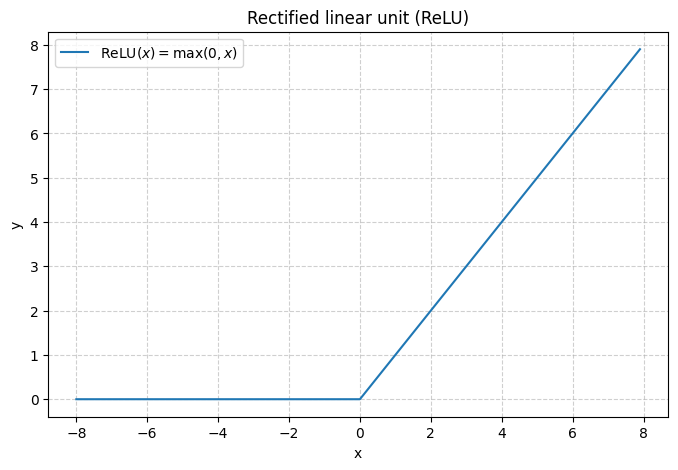

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(x, y, label='$\\mathrm{ReLU}(x) = \\max(0, x)$', linestyle='-')

plt.title('Rectified linear unit (ReLU)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

When $x < 0$, the derivative of our ReLU function is $0$. When $x > 0$, the derivative of our ReLU function is $1$. When $x = 0$, the derivative of our ReLU function is undefined but it doesn't matter in practice - we just have it take the left-hand side value of $0$ by convention.

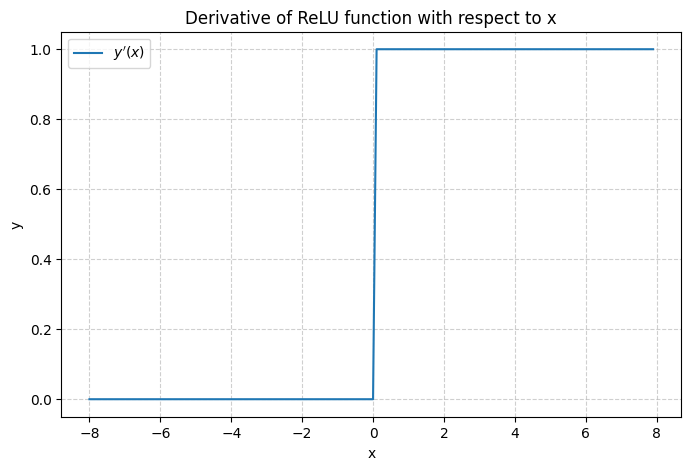

In [5]:
from mindspore import grad

def forward(x):
    return ops.relu(x)

y_prime = grad(forward)(mindspore.Tensor(x))
y_prime = y_prime.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(x, y_prime, label='$y\'(x)$', linestyle='-')

plt.title('Derivative of ReLU function with respect to x')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

The ReLU function behaves well in deep neural networks and solves the historical issue of vanishing gradients. A variant of ReLU called _parametrized_ ReLU was introduced in a paper in 2015 but let's skip it for the sake of simplicity.

### 5.1.2.2. Sigmoid Function

The sigmoid function is defined as below.

$$
\begin{align}
\mathrm{sigmoid}(x) = \frac{1}{1 + e^{-x}}
\end{align}
$$

The sigmoid function produces outputs in the range $(0, 1)$. Its output values are close to $0$ for large negative values and close to $1$ for large positive values.

It is a smooth approximation to the thresholding function which simply takes value $0$ for negative inputs and $1$ for non-negative inputs. While not much used directly in hidden layers within modern deep neural networks due to the vanishing gradients issue, we'll revisit it in future chapters when we discuss _recurrent neural networks_ \(RNN\).

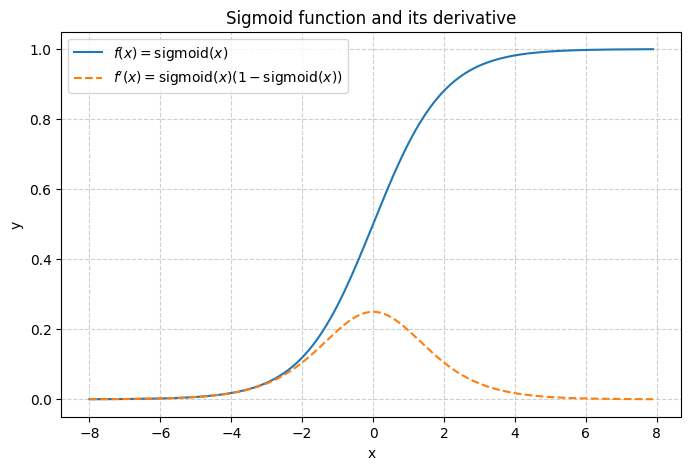

In [6]:
x = ops.arange(-8.0, 8.0, 0.1)

def forward(x):
    return ops.sigmoid(x)

y = forward(x)
y_prime = grad(forward)(x)
x, y, y_prime = x.asnumpy(), y.asnumpy(), y_prime.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(x, y, label='$f(x) = \\mathrm{sigmoid}(x)$', linestyle='-')
plt.plot(x, y_prime, label='$f\'(x) = \\mathrm{sigmoid}(x)(1 - \\mathrm{sigmoid}(x))$', linestyle='--')

plt.title('Sigmoid function and its derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

### 5.1.2.3. Tanh Function

The hyperbolic tangent is defined as below. Its output values lie in the range $(-1, 1)$.

$$
\begin{align}
\tanh(x) = \frac{1 - e^{-2x}}{1 + e^{-2x}}
\end{align}
$$

Notice that the $\tanh$ function approximates a linear transformation for values of $x$ near zero. Its derivative is given below.

$$
\begin{align}
\frac{d}{dx} \tanh(x) = 1 - \tanh^2(x)
\end{align}
$$

The $\tanh$ function and its derivative plotted below.

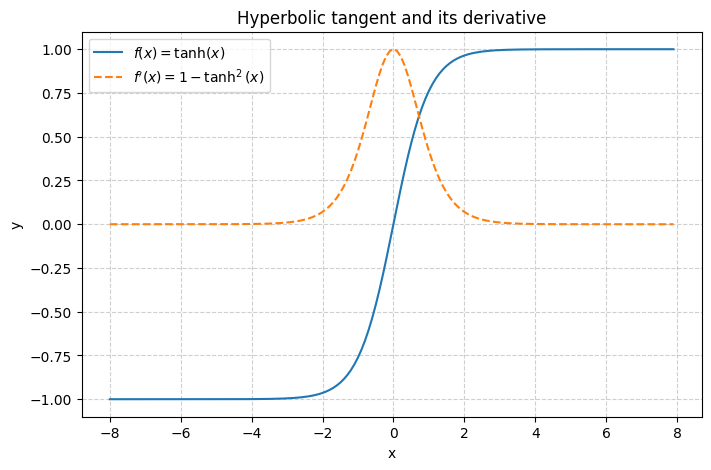

In [7]:
x = ops.arange(-8.0, 8.0, 0.1)

def forward(x):
    return ops.tanh(x)

y = forward(x)
y_prime = grad(forward)(x)
x, y, y_prime = x.asnumpy(), y.asnumpy(), y_prime.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(x, y, label='$f(x) = \\tanh(x)$', linestyle='-')
plt.plot(x, y_prime, label='$f\'(x) = 1 - \\tanh^2(x)$', linestyle='--')

plt.title('Hyperbolic tangent and its derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

## 5.1.3. Summary and Discussion

We learned about activation functions in this chapter and how they help introduce much needed non-linearity to our deep neural networks to learn the non-linear _hidden representation_ of our underlying data in many real-world deep learning scenarios.